In [40]:
# load the psth 

import numpy as np
from create_psth import load_psth_raster_from_zarr, load_psth_raster_from_zarr, mean_firing_rate_matrix, plot_psth_raster_for_units,load_zarr
from behavior_utils import find_trials
from general_utils import smart_read_csv

# 0.  Load the pre‑computed PSTH cube
session='ecephys_753125_2024-10-10_14-41-23_sorted_2024-11-09_20-18-36'
binsize='0.1'
psth_da = load_zarr(f"/root/capsule/scratch/{session}_{binsize}s.zarr")
df_combined_behavior_summary=smart_read_csv(f"/root/capsule/data/regression_result/behavior_summary-{session}.csv")

In [89]:
from ephys_dimension_reduction_dPCA import tdr_from_psth

align = "go_cue"

# IDs to keep (already ints)
keep_ids = np.asarray(df_combined_behavior_summary['response_trials'][0], dtype=int)

# Full latent (all go_cue trials)
latent_full = np.asarray(df_combined_behavior_summary['ForagingCompareThreshold-value-1'][0], dtype=float)

out = tdr_from_psth(
    psth_da,
    latent=latent_full,          
    align=align,
    time_window=(-2, 0),
    include_trials=keep_ids,    # trial IDs to keep
    require_all_ids=True,
    # projection_time_window=None  # optional; None = full time window in psth_da
)

# Outputs you likely want:
w = out["axis_w"]                            # neuronal dimension (N_units,)
y_fit = out["projection"]                    # per-trial scalar in fit window (T_used,)
Y_trace = out["projection_trace"]            # per-trial time course (T_used, Tt)
t = out["time_for_projection"]               # time vector (Tt,)
ids = out["trial_ids"]                       # IDs in the same order as rows of Y_trace


In [90]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

def plot_tdr_trace_by_quantile(
    Y: np.ndarray,
    t: np.ndarray,
    latent: np.ndarray,
    n_quantiles: int = 5,
    *,
    y_fit: np.ndarray = None,
    group_by: str = "latent",    # "latent" or "y_fit"
    ci: str = "sem",             # "sem" or "none"
    show_trials: bool = False,
    cmap: str = "viridis",
    title: str = "TDR projection by quantiles",
    alpha_trials: float = 0.08,
    lw_mean: float = 2.0,
    smooth: dict | None = None,  # e.g., {"method":"gaussian","sigma":0.05,"unit":"s"}
    legend_ci_patch: bool = False,  # add a faint patch in legend to indicate CI color
):
    """
    Plot TDR projection traces grouped by quantiles with optional smoothing.
    Legend is placed outside and uses explicit handles so colors always match.
    """

    # ---- helpers (short versions) ----
    def _build_gaussian_kernel(sigma_pts: float, truncate: float = 3.0) -> np.ndarray:
        sigma_pts = float(max(sigma_pts, 1e-6))
        half = int(np.ceil(truncate * sigma_pts))
        xk = np.arange(-half, half + 1, dtype=float)
        k = np.exp(-0.5 * (xk / sigma_pts) ** 2)
        return k / k.sum()

    def _build_moving_kernel(window_pts: int) -> np.ndarray:
        window_pts = int(max(1, window_pts))
        if window_pts % 2 == 0:
            window_pts += 1
        k = np.ones(window_pts, dtype=float)
        return k / k.sum()

    def _nanaware_convolve_same(y: np.ndarray, k: np.ndarray) -> np.ndarray:
        out = np.empty_like(y, dtype=float)
        for i in range(y.shape[0]):
            row = y[i]
            valid = np.isfinite(row).astype(float)
            data = np.nan_to_num(row, nan=0.0)
            num = np.convolve(data, k, mode="same")
            den = np.convolve(valid, k, mode="same")
            sm = np.divide(num, den, out=np.full_like(num, np.nan), where=den > 1e-12)
            out[i] = sm
        return out

    def _maybe_smooth(Yin: np.ndarray, tvec: np.ndarray, spec: dict | None) -> np.ndarray:
        if not spec:
            return Yin
        method = spec.get("method", "gaussian").lower()
        unit = spec.get("unit", "s").lower()
        truncate = float(spec.get("truncate", 3.0))
        if unit == "s":
            dt = float(np.median(np.diff(tvec)))
            if method == "gaussian":
                sigma = float(spec.get("sigma", 0.05))  # seconds
                k = _build_gaussian_kernel(max(sigma, 1e-6) / max(dt, 1e-9), truncate)
            else:
                window = float(spec.get("window", 0.05))  # seconds
                k = _build_moving_kernel(int(round(window / max(dt, 1e-9))))
        else:  # samples
            if method == "gaussian":
                k = _build_gaussian_kernel(float(spec.get("sigma", 5)), truncate)
            else:
                k = _build_moving_kernel(int(spec.get("window", 5)))
        return _nanaware_convolve_same(Yin, k)

    # ---- validations ----
    Y = np.asarray(Y); t = np.asarray(t).reshape(-1)
    if Y.ndim != 2 or Y.shape[1] != t.size:
        raise ValueError("Y must be (n_trials, n_timepoints) and match t length")

    if group_by == "latent":
        x = np.asarray(latent).reshape(-1)
    elif group_by == "y_fit":
        if y_fit is None: raise ValueError("y_fit must be provided when group_by='y_fit'")
        x = np.asarray(y_fit).reshape(-1)
    else:
        raise ValueError("group_by must be 'latent' or 'y_fit'")

    if x.size != Y.shape[0]:
        raise ValueError(f"{group_by} length must match number of trials in Y")

    # drop invalid trials
    good = np.isfinite(x) & np.isfinite(Y).any(axis=1)
    Y = Y[good]; x = x[good]
    if Y.shape[0] < n_quantiles:
        raise ValueError("Not enough valid trials to form the requested quantiles.")

    # smooth first (per trial)
    Y_sm = _maybe_smooth(Y, t, smooth)

    # quantile binning
    edges = np.nanquantile(x, np.linspace(0, 1, n_quantiles + 1))
    for i in range(1, len(edges)):
        if edges[i] <= edges[i-1]:
            edges[i] = edges[i-1] + np.finfo(float).eps
    q_idx = np.digitize(x, edges[1:-1], right=True)

    # ---- plot ----
    fig, ax = plt.subplots(figsize=(20, 8))
    if show_trials:
        ax.plot(t, Y_sm.T, color="0.6", alpha=alpha_trials, linewidth=0.6, zorder=1)

    cm = get_cmap(cmap, n_quantiles)

    legend_handles = []
    legend_labels = []

    for q in range(n_quantiles):
        idx = np.where(q_idx == q)[0]
        if idx.size == 0:
            continue
        color = cm(q)
        Yq = Y_sm[idx]
        mean_q = np.nanmean(Yq, axis=0)
        ax.plot(t, mean_q, color=color, linewidth=lw_mean, zorder=3)
        if ci == "sem":
            sem_q = np.nanstd(Yq, axis=0) / max(1, np.sqrt(idx.size))
            ax.fill_between(t, mean_q - sem_q, mean_q + sem_q, color=color, alpha=0.25, zorder=2)

        # explicit legend handle for this quantile (line + optional patch)
        line_handle = Line2D([0], [0], color=color, lw=lw_mean)
        if legend_ci_patch and ci == "sem":
            patch_handle = Patch(facecolor=color, alpha=0.25, edgecolor='none')
            legend_handles.append((line_handle, patch_handle))
        else:
            legend_handles.append(line_handle)

        legend_labels.append(f"Q{q+1}/{n_quantiles} [{edges[q]:.3g}, {edges[q+1]:.3g}] n={idx.size}")

    ax.axhline(0, color="k", linewidth=0.8, linestyle="--", zorder=0)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Projection (a.u.)")
    ax.set_title(title + f" (by {group_by})")

    # legend outside with explicit handles
    if legend_handles:
        ax.legend(
            legend_handles,
            legend_labels,
            frameon=False,
            fontsize=9,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0,
            handlelength=2.8,
            handletextpad=0.8,
        )

    fig.tight_layout(rect=[0, 0, 0.82, 1])
    plt.show()


/tmp/ipykernel_10675/1144800680.py:114: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = get_cmap(cmap, n_quantiles)


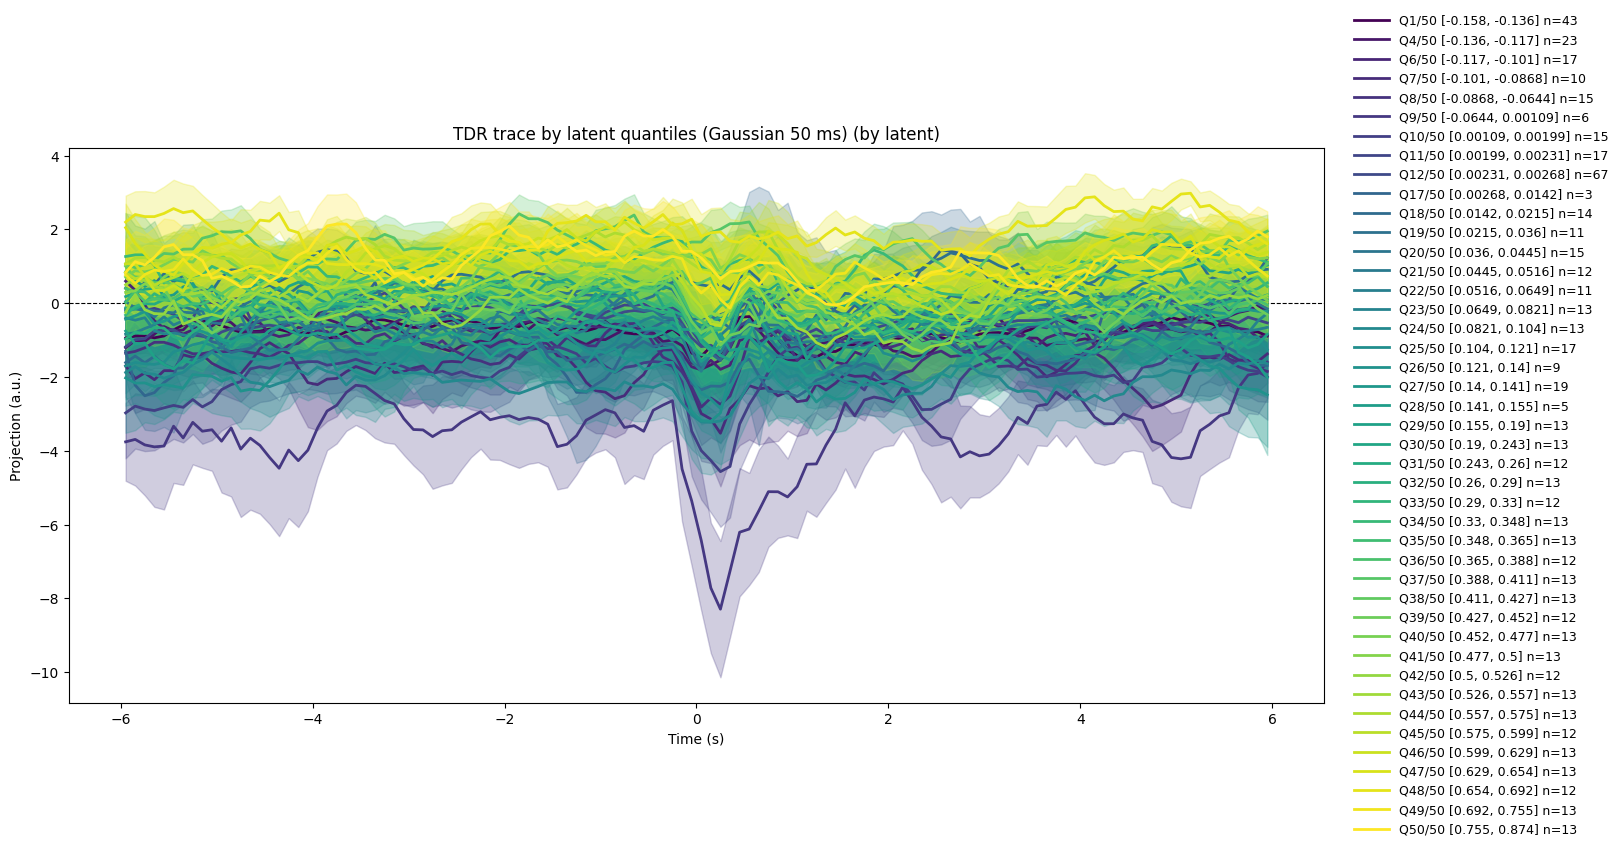

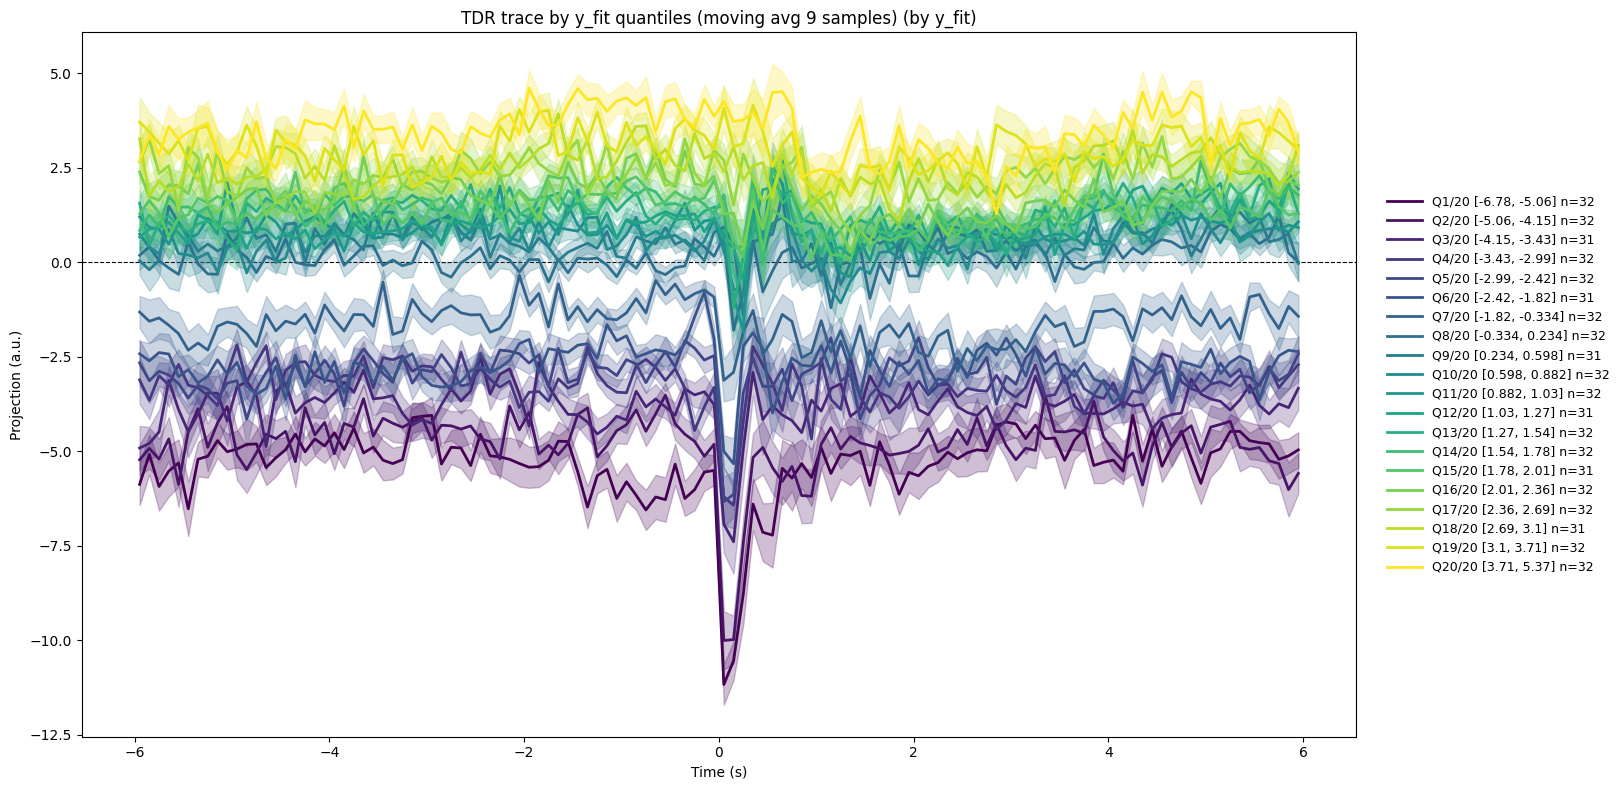

In [91]:
# Get outputs
Y = out["projection_trace"]           # (n_trials, n_timepoints)
t = out["time_for_projection"]        # (n_timepoints,)
y_fit = out["projection"]             # (n_trials,)
latent_inc = latent_full

# 1) Gaussian smoothing with sigma = 50 ms before averaging
plot_tdr_trace_by_quantile(
    Y, t, latent=latent_inc, n_quantiles=50,
    group_by="latent", ci="sem", show_trials=False,
    smooth={"method":"moving", "window":5, "unit":"samples"},
    title="TDR trace by latent quantiles (Gaussian 50 ms)"
)

# 2) Moving-average smoothing with a 9-sample window
plot_tdr_trace_by_quantile(
    Y, t, latent=latent_inc, n_quantiles=20,
    y_fit=y_fit, group_by="y_fit", ci="sem",
    smooth={"method":"moving", "window":1, "unit":"samples"},
    title="TDR trace by y_fit quantiles (moving avg 9 samples)"
)
